In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error

data = pd.read_csv("CarDekho_Car_Data.csv")

print("Shape:", data.shape)
data.head()

Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
print("Shape:", data.shape)
print("\nData Types:")
print(data.dtypes)
print("\nMissing Values:")
print(data.isnull().sum())
print("\nDuplicate Rows:", data.duplicated().sum())
print("\nSummary Statistics:")
print(data.describe())

Shape: (301, 9)

Data Types:
Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type            str
Seller_Type          str
Transmission         str
Owner              int64
dtype: object

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Duplicate Rows: 2

Summary Statistics:
              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000  

In [4]:
print("Roll number mod 3:", 150096724135 % 3)

diesel_data = data[data["Fuel_Type"] == "Diesel"].copy()

print("Total Diesel rows:", len(diesel_data))

if len(diesel_data) < 150:
    petrol_data = data[data["Fuel_Type"] == "Petrol"].copy()
    needed = 150 - len(diesel_data)
    parth_data = pd.concat(
        [diesel_data, petrol_data.head(needed)],
        ignore_index=True
    )
else:
    parth_data = diesel_data.copy()

print("Personalized dataset rows:", len(parth_data))
print("\nFuel types in personalized dataset:")
print(parth_data["Fuel_Type"].value_counts())

parth_data.head()

Roll number mod 3: 1
Total Diesel rows: 60
Personalized dataset rows: 150

Fuel types in personalized dataset:
Fuel_Type
Petrol    90
Diesel    60
Name: count, dtype: int64


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
1,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
2,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
3,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
4,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0


In [ ]:
parth_data = parth_data.drop_duplicates().copy()
parth_data["Year"] = pd.to_numeric(parth_data["Year"], errors="coerce")
parth_data["Selling_Price"] = pd.to_numeric(
    parth_data["Selling_Price"], errors="coerce"
)
parth_data["Kms_Driven"] = pd.to_numeric(
    parth_data["Kms_Driven"], errors="coerce"
)
parth_data["car_age"] = 2026 - parth_data["Year"]

parth_data["car_age"] = parth_data["car_age"].fillna(
    parth_data["car_age"].median()
)

parth_data["Kms_Driven"] = parth_data["Kms_Driven"].fillna(
    parth_data["Kms_Driven"].median()
)

parth_data["Selling_Price"] = parth_data["Selling_Price"].fillna(
    parth_data["Selling_Price"].median()
)

for col in ["Fuel_Type", "Seller_Type", "Transmission", "Owner"]:
    parth_data[col] = parth_data[col].fillna(parth_data[col].mode()[0])

print("Shape after cleaning:", parth_data.shape)
print("\nMissing values after cleaning:")
print(parth_data.isnull().sum())

Shape after cleaning: (148, 10)

Missing values after cleaning:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
car_age          0
dtype: int64


In [6]:
print("Selling Price Statistics:")
print(parth_data["Selling_Price"].describe())

print("\nKms Driven Statistics:")
print(parth_data["Kms_Driven"].describe())

q1_price = parth_data["Selling_Price"].quantile(0.25)
q3_price = parth_data["Selling_Price"].quantile(0.75)
iqr_price = q3_price - q1_price

q1_km = parth_data["Kms_Driven"].quantile(0.25)
q3_km = parth_data["Kms_Driven"].quantile(0.75)
iqr_km = q3_km - q1_km

price_outliers = parth_data[
    (parth_data["Selling_Price"] < q1_price - 1.5 * iqr_price) |
    (parth_data["Selling_Price"] > q3_price + 1.5 * iqr_price)
]

km_outliers = parth_data[
    (parth_data["Kms_Driven"] < q1_km - 1.5 * iqr_km) |
    (parth_data["Kms_Driven"] > q3_km + 1.5 * iqr_km)
]

print("\nSelling Price outliers:", len(price_outliers))
print("Kms Driven outliers:", len(km_outliers))

Selling Price Statistics:
count    148.000000
mean       6.074054
std        6.048292
min        0.350000
25%        1.950000
50%        4.550000
75%        7.450000
max       35.000000
Name: Selling_Price, dtype: float64

Kms Driven Statistics:
count       148.000000
mean      41426.182432
std       31339.596455
min        1200.000000
25%       16425.000000
50%       40794.000000
75%       56000.250000
max      197176.000000
Name: Kms_Driven, dtype: float64

Selling Price outliers: 12
Kms Driven outliers: 5


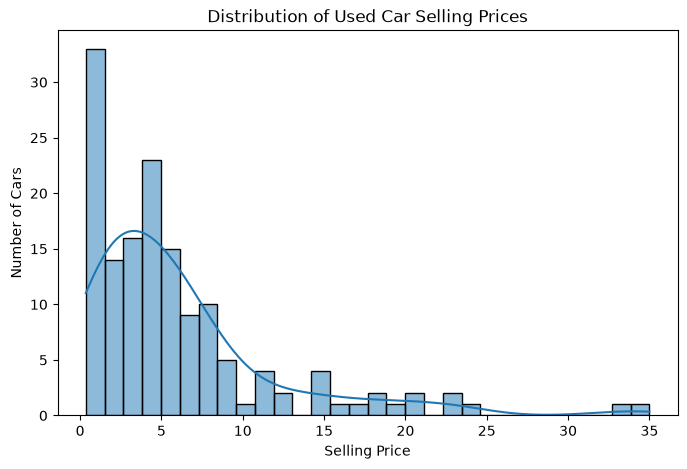

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    parth_data["Selling_Price"],
    bins=30,
    kde=True
)

plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.title("Distribution of Used Car Selling Prices")

plt.show()

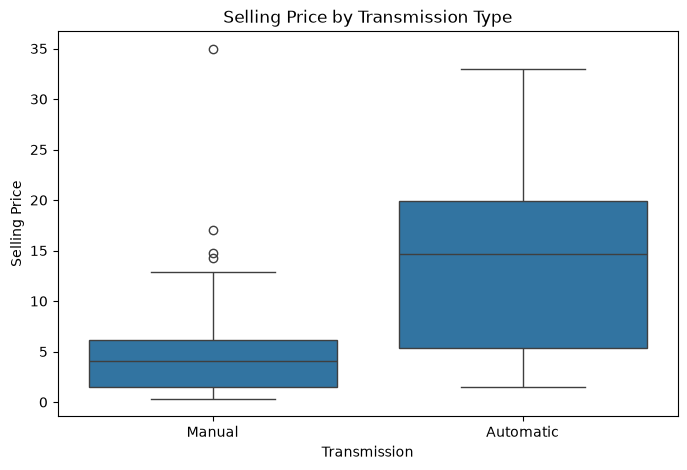

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=parth_data,
    x="Transmission",
    y="Selling_Price"
)

plt.xlabel("Transmission")
plt.ylabel("Selling Price")
plt.title("Selling Price by Transmission Type")

plt.show()

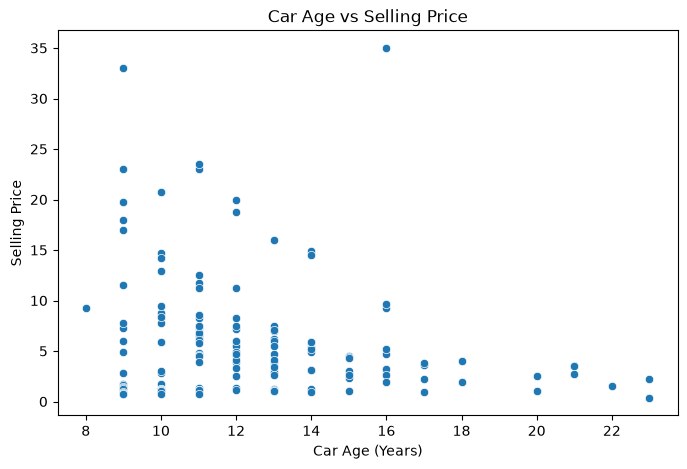

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=parth_data,
    x="car_age",
    y="Selling_Price"
)

plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")
plt.title("Car Age vs Selling Price")

plt.show()

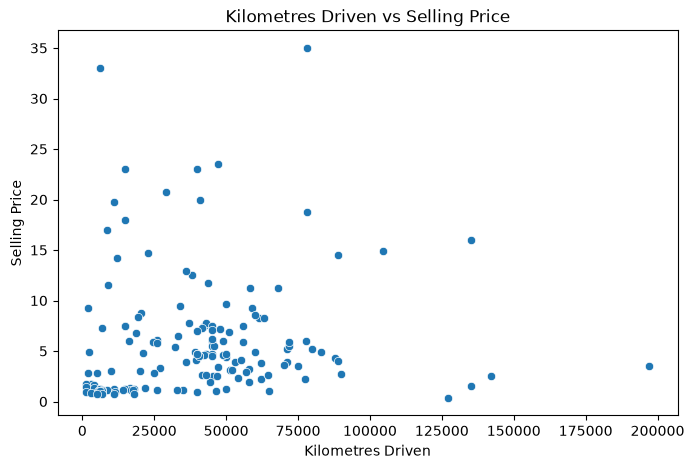

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=parth_data,
    x="Kms_Driven",
    y="Selling_Price"
)

plt.xlabel("Kilometres Driven")
plt.ylabel("Selling Price")
plt.title("Kilometres Driven vs Selling Price")

plt.show()

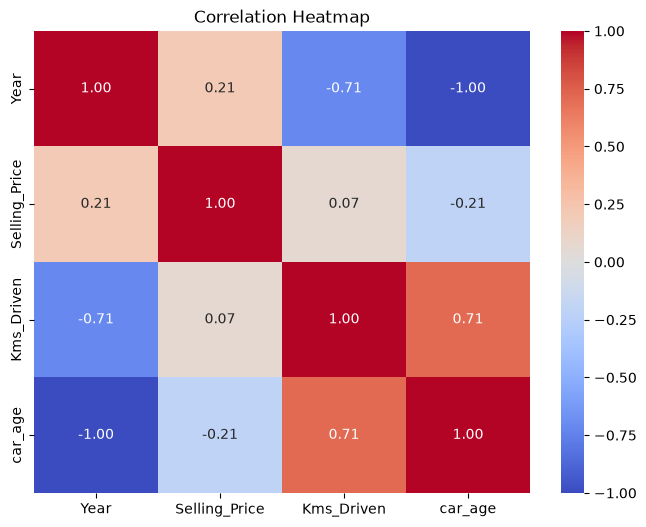

In [11]:
numeric_data = parth_data[
    [
        "Year",
        "Selling_Price",
        "Kms_Driven",
        "car_age"
    ]
]

corr = numeric_data.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [12]:
X = parth_data[
    [
        "car_age",
        "Kms_Driven",
        "Fuel_Type",
        "Transmission",
        "Owner"
    ]
]

y = parth_data["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (118, 5)
Testing data: (30, 5)


In [ ]:
numeric_features = ["car_age", "Kms_Driven"]
categorical_features = ["Fuel_Type", "Transmission", "Owner"]
preprocessor = ColumnTransformer(
    [
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

model = make_pipeline(
    preprocessor,
    LinearRegression()
)
model.fit(X_train, y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
train_rmse = np.sqrt(
    mean_squared_error(y_train, train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, test_pred)
)
print("Baseline Linear Regression")
print("--------------------------")
print("Train R-squared:", train_r2)
print("Test R-squared:", test_r2)
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Baseline Linear Regression
--------------------------
Train R-squared: 0.4551566228919258
Test R-squared: 0.6376842653978279
Train RMSE: 3.99915984267564
Test RMSE: 4.721285653329601


In [14]:
X = parth_data[
    [
        "car_age",
        "Kms_Driven",
        "Fuel_Type",
        "Transmission",
        "Owner"
    ]
]

y = np.log1p(parth_data["Selling_Price"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

preprocessor = ColumnTransformer(
    [
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            ["Fuel_Type", "Transmission", "Owner"]
        )
    ],
    remainder="passthrough"
)

log_model = make_pipeline(
    preprocessor,
    LinearRegression()
)

log_model.fit(X_train, y_train)

train_pred_log = log_model.predict(X_train)
test_pred_log = log_model.predict(X_test)

train_pred = np.expm1(train_pred_log)
test_pred = np.expm1(test_pred_log)

train_r2_log = r2_score(
    np.expm1(y_train),
    train_pred
)

test_r2_log = r2_score(
    np.expm1(y_test),
    test_pred
)

test_rmse_log = np.sqrt(
    mean_squared_error(
        np.expm1(y_test),
        test_pred
    )
)

print("Log-Transform Model")
print("-------------------")
print("Train R-squared:", train_r2_log)
print("Test R-squared:", test_r2_log)
print("Test RMSE:", test_rmse_log)

Log-Transform Model
-------------------
Train R-squared: 0.4518720660821871
Test R-squared: 0.6922900828423737
Test RMSE: 4.350983403022503


In [15]:
X = parth_data[
    [
        "car_age",
        "Kms_Driven",
        "Fuel_Type",
        "Transmission",
        "Owner",
        "Present_Price",
        "Seller_Type"
    ]
]

y = parth_data["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

categorical_features = [
    "Fuel_Type",
    "Transmission",
    "Owner",
    "Seller_Type"
]

preprocessor = ColumnTransformer(
    [
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

improved_model = make_pipeline(
    preprocessor,
    LinearRegression()
)

improved_model.fit(X_train, y_train)

train_pred = improved_model.predict(X_train)
test_pred = improved_model.predict(X_test)

train_r2_improved = r2_score(y_train, train_pred)
test_r2_improved = r2_score(y_test, test_pred)

train_rmse_improved = np.sqrt(
    mean_squared_error(y_train, train_pred)
)

test_rmse_improved = np.sqrt(
    mean_squared_error(y_test, test_pred)
)

print("Improved Linear Regression")
print("--------------------------")
print("Train R-squared:", train_r2_improved)
print("Test R-squared:", test_r2_improved)
print("Train RMSE:", train_rmse_improved)
print("Test RMSE:", test_rmse_improved)

Improved Linear Regression
--------------------------
Train R-squared: 0.9014746480614804
Test R-squared: 0.8569732124779321
Train RMSE: 1.7006185900026516
Test RMSE: 2.9663703538337955


In [16]:
print("MODEL ITERATION COMPARISON")
print("==========================")

print("\nBaseline Model")
print("Test R-squared:", test_r2)
print("Test RMSE:", test_rmse)

print("\nLog-Transform Model")
print("Test R-squared:", test_r2_log)
print("Test RMSE:", test_rmse_log)

print("\nImproved Feature Model")
print("Train R-squared:", train_r2_improved)
print("Test R-squared:", test_r2_improved)
print("Test RMSE:", test_rmse_improved)

MODEL ITERATION COMPARISON

Baseline Model
Test R-squared: 0.6376842653978279
Test RMSE: 4.721285653329601

Log-Transform Model
Test R-squared: 0.6922900828423737
Test RMSE: 4.350983403022503

Improved Feature Model
Train R-squared: 0.9014746480614804
Test R-squared: 0.8569732124779321
Test RMSE: 2.9663703538337955


In [18]:
print("FINAL MODEL")
print("-----------")
print("Train R-squared:", train_r2_improved)
print("Test R-squared:", test_r2_improved)
print("Train RMSE:", train_rmse_improved)
print("Test RMSE:", test_rmse_improved)
print("Fuel types used:")
print(parth_data["Fuel_Type"].value_counts())

FINAL MODEL
-----------
Train R-squared: 0.9014746480614804
Test R-squared: 0.8569732124779321
Train RMSE: 1.7006185900026516
Test RMSE: 2.9663703538337955
Fuel types used:
Fuel_Type
Petrol    90
Diesel    58
Name: count, dtype: int64
